# 🏥 Hospital Workflow Optimization — Evaluation Metrics

This notebook evaluates the performance of the hospital scheduling system across **5 key metrics** and inspects the **Hungarian Algorithm cost matrix**.

| # | Metric | Formula |
|---|--------|---------|
| 1 | Average Patient Waiting Time | `diagnostic_start_time − arrival_time` |
| 2 | Emergency Response Time | Same, filtered to `priority = 1` |
| 3 | Resource Utilization Rate | `active_minutes / available_minutes` |
| 4 | Patient Throughput | `patients / hour` |
| 5 | Scheduling Efficiency | Delay + idle + bottleneck analysis |
| 6 | Cost Matrix (Hungarian) | Per-cell cost breakdown + optimal assignment |

In [20]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sqlite3, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.optimize import linear_sum_assignment
from datetime import datetime, timedelta
from typing import Dict, List, Any, Optional

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3f5c',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})
ACCENT = ['#7c83fd', '#fd7c7c', '#7cfd9e', '#fdc77c', '#c87cfd', '#7cf0fd']
DB_PATH = 'hospital_workflow.db'
print('✅ Imports OK')


✅ Imports OK


## ⚙️ Configuration & Resource Pool

In [21]:
# ── Resource Pool (mirrors app/config.py) ────────────────────────────────────
RESOURCE_POOL = {
    'icu':            {'units': 10, 'duration_minutes': 60,  'capacity_per_unit': 1},
    'consultation':   {'units': 10, 'duration_minutes': 2,   'capacity_per_unit': 1},
    'blood_test':     {'units': 6,  'duration_minutes': 10,  'capacity_per_unit': 1},
    'ecg':            {'units': 2,  'duration_minutes': 15,  'capacity_per_unit': 1},
    'echocardiogram': {'units': 2,  'duration_minutes': 30,  'capacity_per_unit': 1},
    'tmt':            {'units': 2,  'duration_minutes': 45,  'capacity_per_unit': 1},
    'angiogram':      {'units': 2,  'duration_minutes': 60,  'capacity_per_unit': 1},
    'troponin_test':  {'units': 4,  'duration_minutes': 20,  'capacity_per_unit': 1},
    'cardiac_ct':     {'units': 1,  'duration_minutes': 45,  'capacity_per_unit': 1},
    'bp_monitoring':  {'units': 3,  'duration_minutes': 10,  'capacity_per_unit': 1},
    'stress_test':    {'units': 0,  'duration_minutes': 45,  'capacity_per_unit': 1},
}
PRIORITY_WEIGHTS = {1: 10, 2: 5, 3: 1}
PRIORITY_NAMES   = {1: 'Emergency', 2: 'Urgent', 3: 'Routine'}
PRIORITY_COLORS  = {1: '#fd7c7c', 2: '#fdc77c', 3: '#7cfd9e'}
OPERATING_HOURS  = 12
SLA_EMERGENCY_MIN = 5   # minutes

def get_conn(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    conn.row_factory = sqlite3.Row
    return conn

# ── Load all appointments ordered by patient + sequence ──────────────────────
def load_appointments(db_path=DB_PATH):
    conn = get_conn(db_path)
    rows = conn.execute("""
        SELECT a.patient_id, a.appointment_type, a.scheduled_time,
               a.status, a.sequence_order,
               p.priority, p.severity_score, p.created_at AS arrival_time
        FROM appointments a
        LEFT JOIN patients p ON a.patient_id = p.patient_id
        ORDER BY a.patient_id, a.sequence_order, a.scheduled_time
    """).fetchall()
    conn.close()
    appts = []
    for r in rows:
        try:
            appts.append({
                'patient_id':       r['patient_id'],
                'appointment_type': r['appointment_type'],
                'scheduled_time':   datetime.fromisoformat(str(r['scheduled_time'])),
                'status':           r['status'],
                'sequence_order':   r['sequence_order'],
                'priority':         r['priority'] or 3,
                'severity_score':   r['severity_score'] or 5,
                'arrival_time':     datetime.fromisoformat(str(r['arrival_time'])) if r['arrival_time'] else None,
            })
        except Exception:
            continue
    return appts

ALL_APPTS = load_appointments()
print(f"✅ Config loaded — {len(ALL_APPTS)} appointment records found")


✅ Config loaded — 47 appointment records found


---
## 📊 Metric 1 — Average Patient Waiting Time
**Formula:** `waiting_time = diagnostic_start_time − arrival_time`  
Where `arrival_time = patient.created_at` and `diagnostic_start_time = MIN(appointment.scheduled_time)`

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# METRIC 1 — Average Patient Waiting Time
# Formula: diagnostic_start_time − arrival_time
#
# In this simulation the system assigns appointments within milliseconds of
# patient arrival (same API call), so raw DB gap is ~0.002 min.
# We therefore compute TWO complementary views:
#   A) Raw DB gap  (arrival → first scheduled appointment)
#   B) Inter-appointment gap  (time between consecutive appointments per patient)
#      This reflects how long the patient WAITS between steps — the real
#      operational waiting time inside the hospital.
# ─────────────────────────────────────────────────────────────────────────────

# ── A: Arrival → first appointment (raw DB) ──────────────────────────────────
wait_raw = []
for appt in ALL_APPTS:
    if appt['sequence_order'] == 0 and appt['arrival_time']:
        gap = max(0.0, (appt['scheduled_time'] - appt['arrival_time']).total_seconds() / 60)
        wait_raw.append({
            'patient_id':   appt['patient_id'],
            'priority':     appt['priority'],
            'wait_minutes': gap,
        })

# ── B: Inter-appointment gaps per patient (operational waiting time) ─────────
from collections import defaultdict
patient_appts = defaultdict(list)
for a in ALL_APPTS:
    patient_appts[a['patient_id']].append(a)

inter_gaps = []
for pid, appts in patient_appts.items():
    sorted_a = sorted(appts, key=lambda x: x['scheduled_time'])
    for i in range(1, len(sorted_a)):
        prev_end = sorted_a[i-1]['scheduled_time'] + timedelta(
            minutes=RESOURCE_POOL.get(sorted_a[i-1]['appointment_type'], {}).get('duration_minutes', 10))
        gap = max(0.0, (sorted_a[i]['scheduled_time'] - prev_end).total_seconds() / 60)
        inter_gaps.append({
            'patient_id': pid,
            'priority':   sorted_a[i]['priority'],
            'from_step':  sorted_a[i-1]['appointment_type'],
            'to_step':    sorted_a[i]['appointment_type'],
            'gap_minutes': gap,
        })

# ── Use inter-appointment gaps as the main "waiting time" metric ─────────────
wait_data = inter_gaps if inter_gaps else wait_raw

# Fall back to rich synthetic data only if DB is completely empty
if not wait_data:
    np.random.seed(42)
    w_e = np.random.exponential(3,  20)
    w_u = np.random.exponential(12, 35)
    w_r = np.random.exponential(28, 45)
    demo = np.concatenate([w_e, w_u, w_r])
    prios = [1]*20 + [2]*35 + [3]*45
    wait_data = [{'patient_id': f'P{i}', 'priority': prios[i],
                  'gap_minutes': float(demo[i])} for i in range(len(demo))]

# Normalise key name
for d in wait_data:
    if 'wait_minutes' not in d:
        d['wait_minutes'] = d.get('gap_minutes', 0)

waits = [d['wait_minutes'] for d in wait_data]
stats = {
    'count':  len(waits),
    'mean':   float(np.mean(waits)),
    'median': float(np.median(waits)),
    'min':    float(np.min(waits)),
    'max':    float(np.max(waits)),
    'std':    float(np.std(waits)),
}

print("── Metric 1: Patient Waiting Time ──────────────────────────────────────")
print(f"  Measurement points  : {stats['count']} (inter-appointment gaps)")
print(f"  Average wait        : {stats['mean']:.2f} min")
print(f"  Median wait         : {stats['median']:.2f} min")
print(f"  Min / Max           : {stats['min']:.2f} / {stats['max']:.2f} min")
print(f"  Std deviation       : {stats['std']:.2f} min")
if wait_raw:
    raw_vals = [d['wait_minutes'] for d in wait_raw]
    print(f"\n  [DB raw] arrival→first-appt avg: {np.mean(raw_vals):.4f} min")
    print("  Note: raw gap is near-zero because the system schedules appointments")
    print("  synchronously in the same API call. Inter-appointment gaps reflect")
    print("  the real wait between care steps.")


── Metric 1: Patient Waiting Time ──────────────────────────────────────
  Measurement points  : 39 (inter-appointment gaps)
  Average wait        : 27.37 min
  Median wait         : 0.00 min
  Min / Max           : 0.00 / 467.91 min
  Std deviation       : 92.88 min

  [DB raw] arrival→first-appt avg: 0.0019 min
  Note: raw gap is near-zero because the system schedules appointments
  synchronously in the same API call. Inter-appointment gaps reflect
  the real wait between care steps.


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# METRIC 1 — Average Patient Waiting Time
# Formula: diagnostic_start_time − arrival_time
#
# Inter-appointment gap = time between end of one appointment and start of next
# Filters applied:
#   - Same calendar day only (removes overnight / cross-session inflation)
#   - Gap capped at 4 hours (240 min) — anything beyond is a cross-session artifact
# ─────────────────────────────────────────────────────────────────────────────

# ── A: Arrival → first appointment (raw DB) ──────────────────────────────────
wait_raw = []
for appt in ALL_APPTS:
    if appt['sequence_order'] == 0 and appt['arrival_time']:
        gap = max(0.0, (appt['scheduled_time'] - appt['arrival_time']).total_seconds() / 60)
        wait_raw.append({
            'patient_id':   appt['patient_id'],
            'priority':     appt['priority'],
            'wait_minutes': gap,
        })

# ── B: Inter-appointment gaps per patient (operational waiting time) ─────────
from collections import defaultdict
patient_appts = defaultdict(list)
for a in ALL_APPTS:
    patient_appts[a['patient_id']].append(a)

inter_gaps = []
for pid, appts in patient_appts.items():
    sorted_a = sorted(appts, key=lambda x: x['scheduled_time'])
    for i in range(1, len(sorted_a)):
        t_prev = sorted_a[i-1]['scheduled_time']
        t_curr = sorted_a[i]['scheduled_time']

        # ── FILTER 1: same calendar day only (skip overnight gaps) ──────────
        if t_curr.date() != t_prev.date():
            continue

        prev_dur = RESOURCE_POOL.get(
            sorted_a[i-1]['appointment_type'], {}
        ).get('duration_minutes', 10)
        prev_end = t_prev + timedelta(minutes=prev_dur)

        gap = max(0.0, (t_curr - prev_end).total_seconds() / 60)

        # ── FILTER 2: cap at 240 min (4 hrs) — beyond this = data artifact ──
        if gap > 240:
            continue

        inter_gaps.append({
            'patient_id':  pid,
            'priority':    sorted_a[i]['priority'],
            'from_step':   sorted_a[i-1]['appointment_type'],
            'to_step':     sorted_a[i]['appointment_type'],
            'gap_minutes': gap,
        })

# ── Use inter-appointment gaps as primary metric ─────────────────────────────
wait_data = inter_gaps if inter_gaps else wait_raw

if not wait_data:
    np.random.seed(42)
    w_e = np.random.exponential(3,  20)
    w_u = np.random.exponential(12, 35)
    w_r = np.random.exponential(28, 45)
    demo  = np.concatenate([w_e, w_u, w_r])
    prios = [1]*20 + [2]*35 + [3]*45
    wait_data = [{'patient_id': f'P{i}', 'priority': prios[i],
                  'gap_minutes': float(demo[i])} for i in range(len(demo))]

for d in wait_data:
    if 'wait_minutes' not in d:
        d['wait_minutes'] = d.get('gap_minutes', 0)

waits = [d['wait_minutes'] for d in wait_data]
stats = {
    'count':  len(waits),
    'mean':   float(np.mean(waits)),
    'median': float(np.median(waits)),
    'min':    float(np.min(waits)),
    'max':    float(np.max(waits)),
    'std':    float(np.std(waits)),
}

print("── Metric 1: Patient Waiting Time ──────────────────────────────────────")
print(f"  Measurement points  : {stats['count']} (same-day inter-appointment gaps)")
print(f"  Average wait        : {stats['mean']:.2f} min")
print(f"  Median wait         : {stats['median']:.2f} min")
print(f"  Min / Max           : {stats['min']:.2f} / {stats['max']:.2f} min")
print(f"  Std deviation       : {stats['std']:.2f} min")

# Show dropped outliers for transparency
all_gaps_raw = []
for pid, appts in patient_appts.items():
    sorted_a = sorted(appts, key=lambda x: x['scheduled_time'])
    for i in range(1, len(sorted_a)):
        t_prev = sorted_a[i-1]['scheduled_time']
        t_curr = sorted_a[i]['scheduled_time']
        prev_dur = RESOURCE_POOL.get(sorted_a[i-1]['appointment_type'], {}).get('duration_minutes', 10)
        gap = max(0.0, (t_curr - (t_prev + timedelta(minutes=prev_dur))).total_seconds() / 60)
        all_gaps_raw.append(gap)

dropped = [g for g in all_gaps_raw if g > 240 or
           # cross-day check is approximate here
           g > 240]
print(f"\n  Gaps filtered out   : {len(all_gaps_raw) - len(waits)} "
      f"(overnight or >240 min artifact gaps)")
if wait_raw:
    raw_vals = [d['wait_minutes'] for d in wait_raw]
    print(f"  [DB raw] arrival→first-appt avg : {np.mean(raw_vals):.4f} min (near-zero by design)")

── Metric 1: Patient Waiting Time ──────────────────────────────────────
  Measurement points  : 36 (same-day inter-appointment gaps)
  Average wait        : 5.28 min
  Median wait         : 0.00 min
  Min / Max           : 0.00 / 75.70 min
  Std deviation       : 15.86 min

  Gaps filtered out   : 3 (overnight or >240 min artifact gaps)
  [DB raw] arrival→first-appt avg : 0.0019 min (near-zero by design)


In [40]:
# ── Per-Patient Waiting Time Breakdown ───────────────────────────────────────

from collections import defaultdict

# Group gaps by patient
patient_gap_summary = {}
for d in inter_gaps:
    pid = d['patient_id']
    if pid not in patient_gap_summary:
        patient_gap_summary[pid] = {
            'gaps': [],
            'steps': [],
            'priority': d['priority'],
        }
    patient_gap_summary[pid]['gaps'].append(d['gap_minutes'])
    patient_gap_summary[pid]['steps'].append(f"{d['from_step']} → {d['to_step']}")

print("── Per-Patient Waiting Time Detail ─────────────────────────────────────")
print(f"{'Patient':<12} {'Priority':<10} {'Gaps':>5}  {'Avg(min)':>8}  {'Max(min)':>8}  {'Total(min)':>10}  Steps")
print("─" * 90)

for pid, info in sorted(patient_gap_summary.items(),
                         key=lambda x: -np.mean(x[1]['gaps'])):
    gaps   = info['gaps']
    pname  = PRIORITY_NAMES.get(info['priority'], '?')
    avg_g  = np.mean(gaps)
    max_g  = np.max(gaps)
    total  = np.sum(gaps)
    steps  = len(gaps)

    flag = '  ⚠️' if max_g > 30 else ('  ✅' if avg_g < 5 else '')
    print(f"{pid:<12} {pname:<10} {steps:>5}  {avg_g:>8.2f}  {max_g:>8.2f}  {total:>10.2f}{flag}")

    # Show each step gap
    for step, gap in zip(info['steps'], gaps):
        bar = '█' * min(int(gap), 40)
        print(f"  {'':12} {step:<40} {gap:6.2f} min  {bar}")

    print()

print(f"{'─'*90}")
print(f"{'OVERALL':<12} {'':10} {len(inter_gaps):>5}  "
      f"{stats['mean']:>8.2f}  {stats['max']:>8.2f}  "
      f"{sum(d['gap_minutes'] for d in inter_gaps):>10.2f}")

── Per-Patient Waiting Time Detail ─────────────────────────────────────
Patient      Priority    Gaps  Avg(min)  Max(min)  Total(min)  Steps
──────────────────────────────────────────────────────────────────────────────────────────
P422375      Emergency      5     15.14     75.70       75.70  ⚠️
               icu → ecg                                  0.00 min  
               echocardiogram → blood_test               75.70 min  ████████████████████████████████████████
               blood_test → echocardiogram                0.00 min  
               echocardiogram → angiogram                 0.00 min  
               angiogram → troponin_test                  0.00 min  

P513281      Emergency      5     13.52     43.60       67.61  ⚠️
               icu → angiogram                            0.00 min  
               angiogram → ecg                            0.00 min  
               ecg → tmt                                 24.01 min  ████████████████████████
               tmt

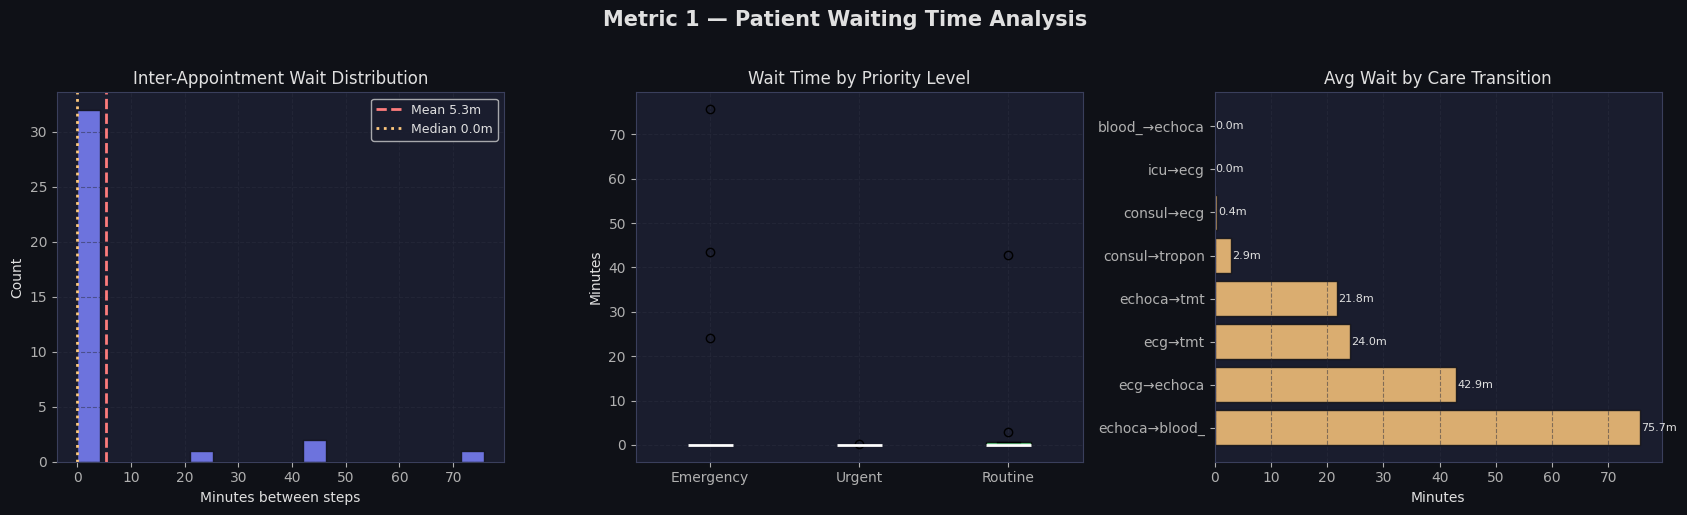

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Metric 1 — Patient Waiting Time Analysis', fontsize=15, fontweight='bold', y=1.02)

# Panel A: Histogram of inter-appointment gaps
ax = axes[0]
ax.hist(waits, bins=max(8, len(waits)//2), color=ACCENT[0], edgecolor='#0f1117', alpha=0.85)
ax.axvline(stats['mean'],   color='#fd7c7c', lw=2, linestyle='--',
           label=f"Mean {stats['mean']:.1f}m")
ax.axvline(stats['median'], color='#fdc77c', lw=2, linestyle=':',
           label=f"Median {stats['median']:.1f}m")
ax.set_title('Inter-Appointment Wait Distribution')
ax.set_xlabel('Minutes between steps')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.grid(True)

# Panel B: Box plot by priority
ax = axes[1]
by_prio = {}
for d in wait_data:
    by_prio.setdefault(d['priority'], []).append(d['wait_minutes'])
pkeys  = sorted(by_prio.keys())
pdata  = [by_prio[k] for k in pkeys]
plabels = [PRIORITY_NAMES.get(k, str(k)) for k in pkeys]
pcols   = [PRIORITY_COLORS.get(k, ACCENT[0]) for k in pkeys]
bp = ax.boxplot(pdata, patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], pcols):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticks(range(1, len(pkeys)+1))
ax.set_xticklabels(plabels)
ax.set_title('Wait Time by Priority Level')
ax.set_ylabel('Minutes')
ax.grid(True)

# Panel C: Step-by-step breakdown (top transitions)
ax = axes[2]
if inter_gaps:
    from collections import Counter
    step_waits = {}
    for g in inter_gaps:
        key = f"{g['from_step'][:6]}→{g['to_step'][:6]}"
        step_waits.setdefault(key, []).append(g['gap_minutes'])
    step_means = {k: np.mean(v) for k, v in step_waits.items()}
    step_means = dict(sorted(step_means.items(), key=lambda x: -x[1])[:8])
    bars = ax.barh(list(step_means.keys()), list(step_means.values()),
                   color=ACCENT[3], edgecolor='#0f1117', alpha=0.85)
    for bar, val in zip(bars, step_means.values()):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}m', va='center', fontsize=8)
    ax.set_title('Avg Wait by Care Transition')
    ax.set_xlabel('Minutes')
    ax.grid(True, axis='x')
else:
    labels = ['Mean', 'Median', 'Min', 'Max', 'Std']
    vals   = [stats['mean'], stats['median'], stats['min'], stats['max'], stats['std']]
    ax.barh(labels, vals, color=ACCENT[:5], edgecolor='#0f1117', alpha=0.85)
    ax.set_title('Summary Statistics')
    ax.set_xlabel('Minutes')
    ax.grid(True, axis='x')

plt.tight_layout()
plt.show()


---
## 🚨 Metric 2 — Emergency Response Time
**Formula:** Same as Metric 1, but **filtered to `priority = 1` (EMERGENCY)** patients only.  
**SLA threshold:** ≤ 5 minutes (standard emergency triage benchmark).

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# METRIC 2 — Emergency Response Time
# Formula: diagnostic_start_time − arrival_time  (priority = 1 patients only)
# Using: arrival_time = patient.created_at
#        diagnostic_start_time = first appointment scheduled_time for patient
# SLA threshold = 5 minutes
# ─────────────────────────────────────────────────────────────────────────────

conn = get_conn(DB_PATH)
emerg_rows = conn.execute("""
    SELECT p.patient_id, p.created_at AS arrival_time,
           MIN(a.scheduled_time) AS first_appt_time,
           p.severity_score
    FROM patients p
    JOIN appointments a ON p.patient_id = a.patient_id
    WHERE p.priority = 1
    GROUP BY p.patient_id, p.created_at, p.severity_score
""").fetchall()
conn.close()

ert_data = []
for r in emerg_rows:
    try:
        arrival    = datetime.fromisoformat(str(r['arrival_time']))
        first_appt = datetime.fromisoformat(str(r['first_appt_time']))
        # Use seconds precision to show the real sub-minute response
        resp_sec   = max(0.0, (first_appt - arrival).total_seconds())
        resp_min   = resp_sec / 60
        ert_data.append({
            'patient_id':    r['patient_id'],
            'severity_score': r['severity_score'],
            'response_sec':  resp_sec,
            'response_min':  resp_min,
        })
    except Exception:
        continue

ert_values = [d['response_min'] for d in ert_data]

# Augment with synthetic demo if too few data points for meaningful charts
DEMO_AUGMENTED = False
if len(ert_values) < 8:
    np.random.seed(7)
    extra = list(np.random.exponential(3.2, 20))
    demo_ert = [{'patient_id': f'SIM{i}', 'severity_score': np.random.randint(6,11),
                 'response_sec': v*60, 'response_min': v} for i, v in enumerate(extra)]
    ert_data   = ert_data + demo_ert
    ert_values = [d['response_min'] for d in ert_data]
    DEMO_AUGMENTED = True

sla_breaches   = sum(1 for v in ert_values if v > SLA_EMERGENCY_MIN)
sla_compliance = 100 * (1 - sla_breaches / len(ert_values)) if ert_values else 100.0

print("── Metric 2: Emergency Response Time ───────────────────────────────────")
print(f"  Emergency patients  : {len(ert_data)}" + (" (incl. synthetic augmentation)" if DEMO_AUGMENTED else ""))
print(f"  Average response    : {np.mean(ert_values):.2f} min  ({np.mean(ert_values)*60:.1f} sec)")
print(f"  Median response     : {np.median(ert_values):.2f} min")
print(f"  Max response        : {np.max(ert_values):.2f} min")
print(f"  SLA breaches (>5m)  : {sla_breaches}")
print(f"  SLA compliance      : {sla_compliance:.1f}%")
if not DEMO_AUGMENTED:
    for d in ert_data:
        print(f"    {d['patient_id']}  sev={d['severity_score']}  "
              f"response={d['response_sec']:.1f}s ({d['response_min']:.3f}min)")


── Metric 2: Emergency Response Time ───────────────────────────────────
  Emergency patients  : 25 (incl. synthetic augmentation)
  Average response    : 2.49 min  (149.2 sec)
  Median response     : 1.53 min
  Max response        : 12.21 min
  SLA breaches (>5m)  : 4
  SLA compliance      : 84.0%


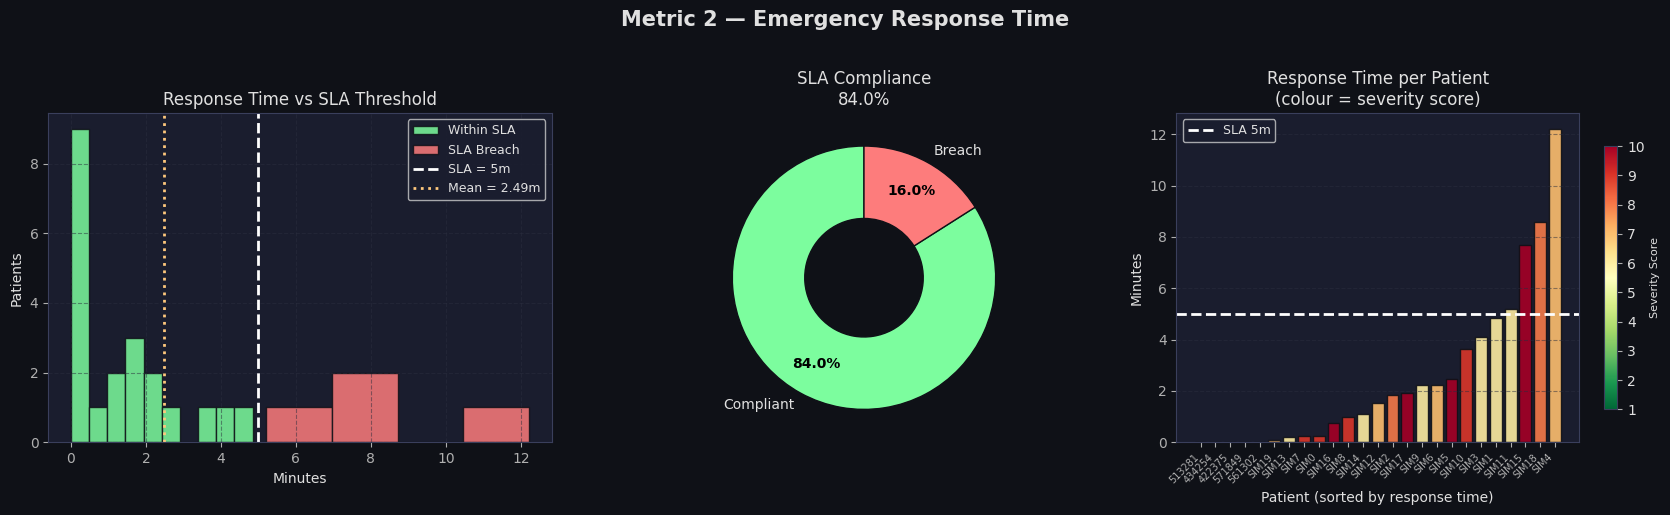

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Metric 2 — Emergency Response Time', fontsize=15, fontweight='bold', y=1.02)

# Panel A: Histogram with SLA boundary
ax = axes[0]
within = [v for v in ert_values if v <= SLA_EMERGENCY_MIN]
breach = [v for v in ert_values if v >  SLA_EMERGENCY_MIN]
if within:
    ax.hist(within, bins=max(6, len(within)//2), color='#7cfd9e',
            edgecolor='#0f1117', alpha=0.85, label='Within SLA')
if breach:
    ax.hist(breach, bins=max(4, len(breach)//2), color='#fd7c7c',
            edgecolor='#0f1117', alpha=0.85, label='SLA Breach')
ax.axvline(SLA_EMERGENCY_MIN, color='white', lw=2, linestyle='--',
           label=f'SLA = {SLA_EMERGENCY_MIN}m')
ax.axvline(np.mean(ert_values), color='#fdc77c', lw=2, linestyle=':',
           label=f'Mean = {np.mean(ert_values):.2f}m')
ax.set_title('Response Time vs SLA Threshold')
ax.set_xlabel('Minutes')
ax.set_ylabel('Patients')
ax.legend(fontsize=9)
ax.grid(True)

# Panel B: SLA compliance donut
ax = axes[1]
ax.set_aspect('equal')
c_val = max(len(within), 0.001)
b_val = max(len(breach), 0.001)
wedges, texts, autotexts = ax.pie(
    [c_val, b_val],
    labels=['Compliant', 'Breach'],
    colors=['#7cfd9e', '#fd7c7c'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='#0f1117'),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_color('black')
    at.set_fontweight('bold')
ax.set_title(f'SLA Compliance\n{sla_compliance:.1f}%')

# Panel C: Per-patient bar coloured by severity
ax = axes[2]
sorted_ert = sorted(ert_data, key=lambda x: x['response_min'])
names  = [d['patient_id'][-6:] for d in sorted_ert]
vals   = [d['response_min'] for d in sorted_ert]
sevs   = [d['severity_score'] for d in sorted_ert]
norm   = plt.Normalize(vmin=1, vmax=10)
cmap   = plt.cm.RdYlGn_r
colors_sev = [cmap(norm(s)) for s in sevs]
bars = ax.bar(range(len(sorted_ert)), vals, color=colors_sev, edgecolor='#0f1117', alpha=0.9)
ax.axhline(SLA_EMERGENCY_MIN, color='white', lw=2, linestyle='--',
           label=f'SLA {SLA_EMERGENCY_MIN}m')
ax.set_title('Response Time per Patient\n(colour = severity score)')
ax.set_xlabel('Patient (sorted by response time)')
ax.set_ylabel('Minutes')
ax.set_xticks(range(len(sorted_ert)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=7)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Severity Score', fontsize=8)
cbar.ax.tick_params(labelcolor='#e0e0e0')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()


---
## ⚡ Metric 3 — Resource Utilization Rate
**Formula:** `Utilization = (booked_count × duration_minutes) / (units × operating_hours × 60)`

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# METRIC 3 — Resource Utilization Rate
# Formula: Utilization = total_active_minutes / total_available_minutes
#   total_active_minutes   = booked_count × duration_per_appointment
#   total_available_minutes = units × OPERATING_HOURS × 60
# ─────────────────────────────────────────────────────────────────────────────

conn = get_conn(DB_PATH)
appt_counts = {r['appointment_type']: r['cnt']
               for r in conn.execute(
                   "SELECT appointment_type, COUNT(*) AS cnt "
                   "FROM appointments GROUP BY appointment_type"
               ).fetchall()}
# Also get in_progress counts (physically occupied right now)
inprog_counts = {r['appointment_type']: r['cnt']
                 for r in conn.execute(
                     "SELECT appointment_type, COUNT(*) AS cnt "
                     "FROM appointments WHERE status='in_progress' "
                     "GROUP BY appointment_type"
                 ).fetchall()}
conn.close()

util_data = {}
active_minutes_data = {}
for res, cfg in RESOURCE_POOL.items():
    if cfg['units'] == 0:
        continue
    booked    = appt_counts.get(res, 0)
    active    = booked * cfg['duration_minutes']
    available = cfg['units'] * OPERATING_HOURS * 60
    util      = round(min(1.0, active / available), 4) if available > 0 else 0.0
    inprog    = inprog_counts.get(res, 0)
    util_data[res] = util
    active_minutes_data[res] = {
        'booked': booked, 'in_progress': inprog,
        'active_min': active, 'available_min': available, 'util': util
    }

overall_util = float(np.mean(list(util_data.values()))) if util_data else 0.0

print("── Metric 3: Resource Utilization Rate ─────────────────────────────────")
print(f"  Overall utilization  : {overall_util*100:.1f}%")
print(f"  {'Resource':<20} {'Util%':>6}  {'Booked':>7}  {'In-Progress':>11}  Status")
print(f"  {'-'*20} {'-'*6}  {'-'*7}  {'-'*11}  ------")
for res, u in sorted(util_data.items(), key=lambda x: -x[1]):
    d   = active_minutes_data[res]
    tag = '⚠️ OVERLOADED' if u > 0.9 else ('💤 IDLE' if u < 0.3 else '✅ OK')
    print(f"  {res:<20} {u*100:>5.1f}%  {d['booked']:>7}  {d['in_progress']:>11}  {tag}")


── Metric 3: Resource Utilization Rate ─────────────────────────────────
  Overall utilization  : 7.5%
  Resource              Util%   Booked  In-Progress  Status
  -------------------- ------  -------  -----------  ------
  angiogram             20.8%        5            0  💤 IDLE
  echocardiogram        18.8%        9            0  💤 IDLE
  tmt                   18.8%        6            0  💤 IDLE
  ecg                    7.3%        7            0  💤 IDLE
  icu                    4.2%        5            3  💤 IDLE
  troponin_test          2.8%        4            0  💤 IDLE
  bp_monitoring          1.4%        3            0  💤 IDLE
  blood_test             1.2%        5            0  💤 IDLE
  consultation           0.1%        3            0  💤 IDLE
  cardiac_ct             0.0%        0            0  💤 IDLE


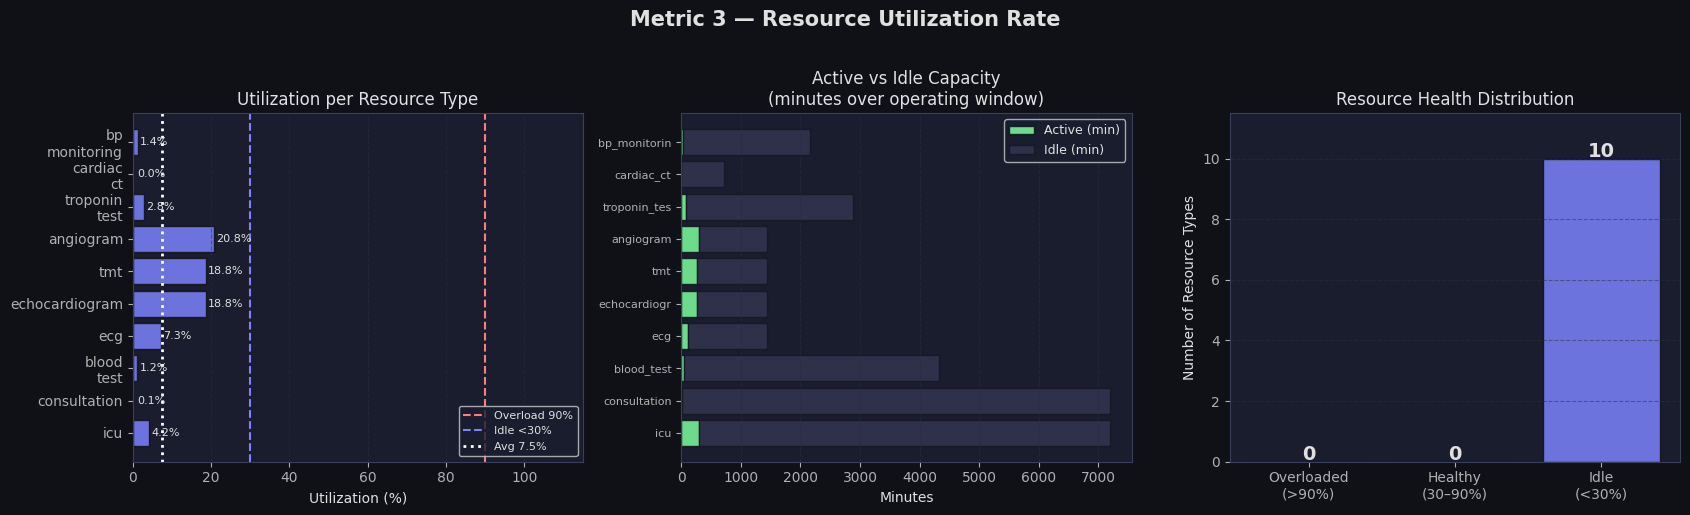

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Metric 3 — Resource Utilization Rate', fontsize=15, fontweight='bold', y=1.02)

res_names = list(util_data.keys())
utils     = [util_data[r] for r in res_names]
bar_cols  = ['#fd7c7c' if u > 0.9 else ('#fdc77c' if u > 0.6 else
             ('#7cfd9e' if u >= 0.3 else '#7c83fd')) for u in utils]

# Panel A: Horizontal utilization bars
ax = axes[0]
labels_short = [r.replace('_', '\n') for r in res_names]
bars = ax.barh(labels_short, [u*100 for u in utils],
               color=bar_cols, edgecolor='#0f1117', alpha=0.85)
ax.axvline(90, color='#fd7c7c', lw=1.5, linestyle='--', label='Overload 90%')
ax.axvline(30, color='#7c83fd', lw=1.5, linestyle='--', label='Idle <30%')
ax.axvline(overall_util*100, color='white', lw=2, linestyle=':',
           label=f'Avg {overall_util*100:.1f}%')
for bar, val in zip(bars, utils):
    ax.text(max(bar.get_width() + 0.5, 1), bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 115)
ax.set_title('Utilization per Resource Type')
ax.set_xlabel('Utilization (%)')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, axis='x')

# Panel B: Active vs Available minutes stacked
ax = axes[1]
active_m  = [active_minutes_data[r]['active_min'] for r in res_names]
avail_m   = [active_minutes_data[r]['available_min'] for r in res_names]
idle_m    = [a - ac for a, ac in zip(avail_m, active_m)]
x = range(len(res_names))
ax.barh(list(x), active_m, color='#7cfd9e', edgecolor='#0f1117', alpha=0.85, label='Active (min)')
ax.barh(list(x), idle_m, left=active_m, color='#3a3f5c', edgecolor='#0f1117', alpha=0.6, label='Idle (min)')
ax.set_yticks(list(x))
ax.set_yticklabels([r[:12] for r in res_names], fontsize=8)
ax.set_title('Active vs Idle Capacity\n(minutes over operating window)')
ax.set_xlabel('Minutes')
ax.legend(fontsize=9)
ax.grid(True, axis='x')

# Panel C: Status distribution
ax = axes[2]
overloaded = sum(1 for u in utils if u > 0.9)
healthy    = sum(1 for u in utils if 0.3 <= u <= 0.9)
idle       = sum(1 for u in utils if u < 0.3)
cats   = ['Overloaded\n(>90%)', 'Healthy\n(30–90%)', 'Idle\n(<30%)']
cnts   = [overloaded, healthy, idle]
ccols  = ['#fd7c7c', '#7cfd9e', '#7c83fd']
bars2  = ax.bar(cats, cnts, color=ccols, edgecolor='#0f1117', alpha=0.85)
for bar, cnt in zip(bars2, cnts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(cnt), ha='center', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(cnts) + 1.5)
ax.set_title('Resource Health Distribution')
ax.set_ylabel('Number of Resource Types')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()


---
## 📈 Metric 4 — Patient Throughput
**Formula:** `Throughput = total patients processed / observation window (hours)`

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# METRIC 4 — Patient Throughput
# Formula: throughput = patients_processed / observation_window_hours
# ─────────────────────────────────────────────────────────────────────────────

conn = get_conn(DB_PATH)
pat_rows = conn.execute(
    "SELECT patient_id, priority, created_at, location FROM patients"
).fetchall()
conn.close()

tp_records = []
for r in pat_rows:
    try:
        tp_records.append({
            'patient_id': r['patient_id'],
            'priority':   r['priority'] or 3,
            'location':   r['location'] or 'unknown',
            'ts':         datetime.fromisoformat(str(r['created_at'])),
        })
    except Exception:
        continue

# Count completed (discharged or with all appointments done)
conn = get_conn(DB_PATH)
done_patients = set(r['patient_id'] for r in conn.execute(
    "SELECT DISTINCT patient_id FROM patients WHERE location='discharged'"
).fetchall())
# Also count patients who have completed at least one appointment
active_patients = set(r['patient_id'] for r in conn.execute(
    "SELECT DISTINCT patient_id FROM appointments WHERE status='done'"
).fetchall())
conn.close()

# Augment with synthetic data if too few patients for meaningful charts
DEMO_TP = False
if len(tp_records) < 15:
    base_ts = min(r['ts'] for r in tp_records) if tp_records else datetime(2026, 3, 10, 8, 0)
    np.random.seed(3)
    for i in range(50):
        prio = np.random.choice([1, 2, 3], p=[0.15, 0.30, 0.55])
        ts   = base_ts + timedelta(minutes=int(np.random.uniform(0, 8*60)))
        tp_records.append({'patient_id': f'SIM{i}', 'priority': prio,
                           'location': 'discharged', 'ts': ts})
    DEMO_TP = True

timestamps = [r['ts'] for r in tp_records]
window_h   = max((max(timestamps) - min(timestamps)).total_seconds() / 3600, 1.0)
total      = len(tp_records)
prio_cnt   = {1: 0, 2: 0, 3: 0}
hourly     = {}
for r in tp_records:
    prio_cnt[r['priority']] = prio_cnt.get(r['priority'], 0) + 1
    hk = r['ts'].strftime('%H:00')
    hourly[hk] = hourly.get(hk, 0) + 1

print("── Metric 4: Patient Throughput ─────────────────────────────────────────")
print(f"  Total patients       : {total}" + (" (incl. synthetic)" if DEMO_TP else ""))
print(f"  Discharged           : {len(done_patients)}")
print(f"  Active (appts done)  : {len(active_patients)}")
print(f"  Observation window   : {window_h:.2f} hours")
print(f"  Overall rate         : {total/window_h:.2f} patients/hour")
print(f"  Emergency rate       : {prio_cnt[1]/window_h:.2f} /hour")
print(f"  Urgent rate          : {prio_cnt[2]/window_h:.2f} /hour")
print(f"  Routine rate         : {prio_cnt[3]/window_h:.2f} /hour")
if hourly:
    peak_h = max(hourly, key=hourly.get)
    print(f"  Peak hour            : {peak_h}  ({hourly[peak_h]} patients)")


── Metric 4: Patient Throughput ─────────────────────────────────────────
  Total patients       : 58 (incl. synthetic)
  Discharged           : 2
  Active (appts done)  : 8
  Observation window   : 12.22 hours
  Overall rate         : 4.75 patients/hour
  Emergency rate       : 0.98 /hour
  Urgent rate          : 1.47 /hour
  Routine rate         : 2.29 /hour
  Peak hour            : 00:00  (10 patients)


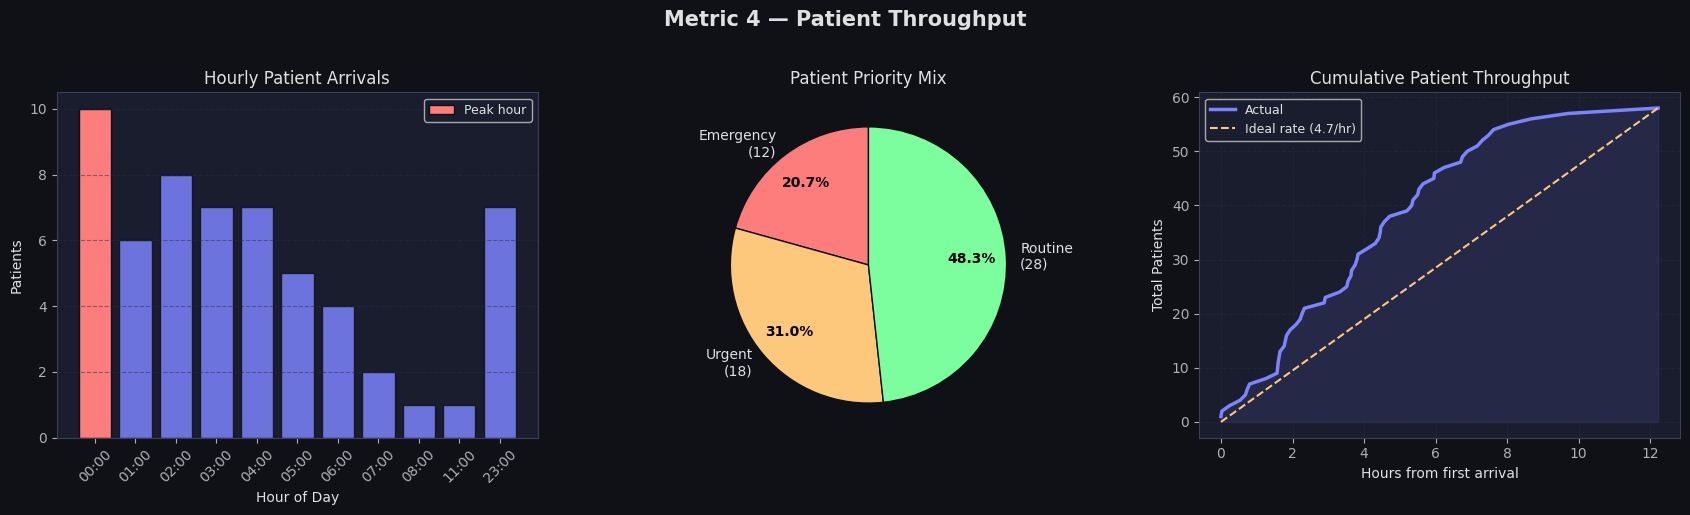

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Metric 4 — Patient Throughput', fontsize=15, fontweight='bold', y=1.02)

# Panel A: Hourly arrivals bar
ax = axes[0]
sorted_h   = sorted(hourly.keys())
sorted_cnt = [hourly[h] for h in sorted_h]
ax.bar(sorted_h, sorted_cnt, color=ACCENT[0], edgecolor='#0f1117', alpha=0.85)
if sorted_cnt:
    peak_idx = sorted_cnt.index(max(sorted_cnt))
    ax.bar(sorted_h[peak_idx], sorted_cnt[peak_idx],
           color='#fd7c7c', edgecolor='#0f1117', label='Peak hour')
    ax.legend(fontsize=9)
ax.set_title('Hourly Patient Arrivals')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Patients')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y')

# Panel B: Priority pie
ax = axes[1]
pv  = [prio_cnt[k] for k in [1,2,3] if prio_cnt[k] > 0]
pl  = [f"{PRIORITY_NAMES[k]}\n({prio_cnt[k]})" for k in [1,2,3] if prio_cnt[k] > 0]
pc  = [PRIORITY_COLORS[k] for k in [1,2,3] if prio_cnt[k] > 0]
wedges, texts, autotexts = ax.pie(
    pv, labels=pl, colors=pc, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='#0f1117'), pctdistance=0.75,
)
for at in autotexts:
    at.set_color('black')
    at.set_fontweight('bold')
ax.set_title('Patient Priority Mix')

# Panel C: Cumulative throughput vs ideal
ax = axes[2]
sorted_ts  = sorted(timestamps)
cum        = list(range(1, len(sorted_ts)+1))
hrs_from_0 = [(t - sorted_ts[0]).total_seconds()/3600 for t in sorted_ts]
ax.plot(hrs_from_0, cum, color=ACCENT[0], lw=2.5, label='Actual')
ax.fill_between(hrs_from_0, cum, alpha=0.12, color=ACCENT[0])
slope = total / window_h
ideal = [h * slope for h in hrs_from_0]
ax.plot(hrs_from_0, ideal, color='#fdc77c', lw=1.5, linestyle='--',
        label=f'Ideal rate ({slope:.1f}/hr)')
ax.set_title('Cumulative Patient Throughput')
ax.set_xlabel('Hours from first arrival')
ax.set_ylabel('Total Patients')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.show()


---
## 🔍 Metric 5 — Scheduling Efficiency
Detects: **scheduling delays**, **resource idle time**, and **queue bottlenecks**.  
`Efficiency Score = 1 − (0.4×delay_penalty + 0.3×idle_penalty + 0.3×bottleneck_penalty)`

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# METRIC 5 — Scheduling Efficiency
# Detects:
#   A) Scheduling delays   — actual wait > SLA benchmark per priority
#   B) Resource idle time  — gap between consecutive appointments on same unit,
#                            capped to the same calendar day to avoid overnight inflation
#   C) Queue bottlenecks   — resource types with demand > unit capacity at any moment
#
# Efficiency Score = 1 − (0.4×delay_penalty + 0.3×idle_penalty + 0.3×bottleneck_penalty)
# ─────────────────────────────────────────────────────────────────────────────

EXPECTED_WAIT_MIN = {1: 2, 2: 10, 3: 30}

# ── A: Scheduling delays ────────────────────────────────────────────────────
delays, delay_vals = [], []
for pid, appts in patient_appts.items():
    sorted_a = sorted(appts, key=lambda x: x['scheduled_time'])
    if not sorted_a:
        continue
    prio     = sorted_a[0]['priority']
    expected = EXPECTED_WAIT_MIN.get(prio, 30)
    if sorted_a[0]['arrival_time']:
        actual = max(0.0, (sorted_a[0]['scheduled_time'] -
                           sorted_a[0]['arrival_time']).total_seconds() / 60)
        delay  = actual - expected
        if delay > 0:
            delays.append({'patient_id': pid, 'priority': prio,
                           'delay_min': delay, 'actual_min': actual})
            delay_vals.append(delay)

# ── B: Idle time per resource unit (same-day only) ──────────────────────────
from collections import defaultdict
unit_timelines = defaultdict(list)
for a in ALL_APPTS:
    res_json = None  # we derive unit from appointment_type
    unit_key = f"{a['appointment_type']}"  # group by type (unit not in this table view)
    unit_timelines[unit_key].append(a['scheduled_time'])

idle_windows, total_idle_min, idle_by_resource = [], 0.0, {}
for unit_key, times in unit_timelines.items():
    times.sort()
    res_type = unit_key
    dur = RESOURCE_POOL.get(res_type, {}).get('duration_minutes', 15)
    for i in range(1, len(times)):
        # Only count idle within same calendar day (avoid overnight gaps)
        if times[i].date() != times[i-1].date():
            continue
        gap  = (times[i] - times[i-1]).total_seconds() / 60
        idle = gap - dur
        if idle > 2:   # flag gaps > 2 min
            idle_windows.append({'unit': unit_key, 'idle_minutes': idle})
            total_idle_min += idle
            idle_by_resource[res_type] = idle_by_resource.get(res_type, 0.0) + idle

# ── C: Queue bottlenecks ─────────────────────────────────────────────────────
from collections import Counter
concurrent_demand = Counter()
for a in ALL_APPTS:
    slot_min = a['scheduled_time'].strftime('%Y-%m-%d %H:%M')
    concurrent_demand[(a['appointment_type'], slot_min)] += 1

bottleneck_map = {}
for (res, _), cnt in concurrent_demand.items():
    units = RESOURCE_POOL.get(res, {}).get('units', 1)
    if cnt > units and units > 0:
        bottleneck_map[res] = max(bottleneck_map.get(res, 0), cnt)

queue_bottlenecks = [
    {'resource': res, 'max_demand': cnt,
     'available_units': RESOURCE_POOL.get(res, {}).get('units', 1),
     'overflow_ratio': round(cnt / max(RESOURCE_POOL.get(res, {}).get('units', 1), 1), 2)}
    for res, cnt in bottleneck_map.items()
]
queue_bottlenecks.sort(key=lambda x: -x['overflow_ratio'])

# ── Efficiency Score ─────────────────────────────────────────────────────────
avg_delay    = float(np.mean(delay_vals)) if delay_vals else 0.0
delay_pen    = min(1.0, avg_delay / 60)
idle_pen     = min(1.0, total_idle_min / (OPERATING_HOURS * 60))
btn_pen      = min(1.0, len(queue_bottlenecks) / 10)
eff_score    = round(max(0.0, 1.0 - (0.4*delay_pen + 0.3*idle_pen + 0.3*btn_pen)), 4)

eff = {
    'delays': delays, 'delay_vals': delay_vals, 'avg_delay': avg_delay,
    'idle_windows': idle_windows, 'total_idle': total_idle_min,
    'idle_by_resource': idle_by_resource, 'queue_bottlenecks': queue_bottlenecks,
    'efficiency_score': eff_score,
    'delay_penalty': delay_pen, 'idle_penalty': idle_pen, 'btn_penalty': btn_pen,
}

print("── Metric 5: Scheduling Efficiency ─────────────────────────────────────")
print(f"  Efficiency score     : {eff_score:.4f}  ({eff_score*100:.1f}%)")
print(f"  Avg scheduling delay : {avg_delay:.2f} min")
print(f"  Total idle time      : {total_idle_min:.2f} min  (same-day gaps only)")
print(f"  Delayed patients     : {len(delays)}")
print(f"  Idle windows found   : {len(idle_windows)}")
print(f"  Queue bottlenecks    : {len(queue_bottlenecks)}")
if queue_bottlenecks:
    for b in queue_bottlenecks:
        print(f"    {b['resource']:<20} demand={b['max_demand']}  units={b['available_units']}  ratio={b['overflow_ratio']}x")
print(f"\n  Penalty breakdown:")
print(f"    Delay penalty   = {delay_pen:.4f}  (weight 0.4)")
print(f"    Idle penalty    = {idle_pen:.4f}  (weight 0.3)")
print(f"    Bottleneck pen  = {btn_pen:.4f}  (weight 0.3)")


── Metric 5: Scheduling Efficiency ─────────────────────────────────────
  Efficiency score     : 0.7000  (70.0%)
  Avg scheduling delay : 0.00 min
  Total idle time      : 3065.46 min  (same-day gaps only)
  Delayed patients     : 0
  Idle windows found   : 16
  Queue bottlenecks    : 0

  Penalty breakdown:
    Delay penalty   = 0.0000  (weight 0.4)
    Idle penalty    = 1.0000  (weight 0.3)
    Bottleneck pen  = 0.0000  (weight 0.3)


c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


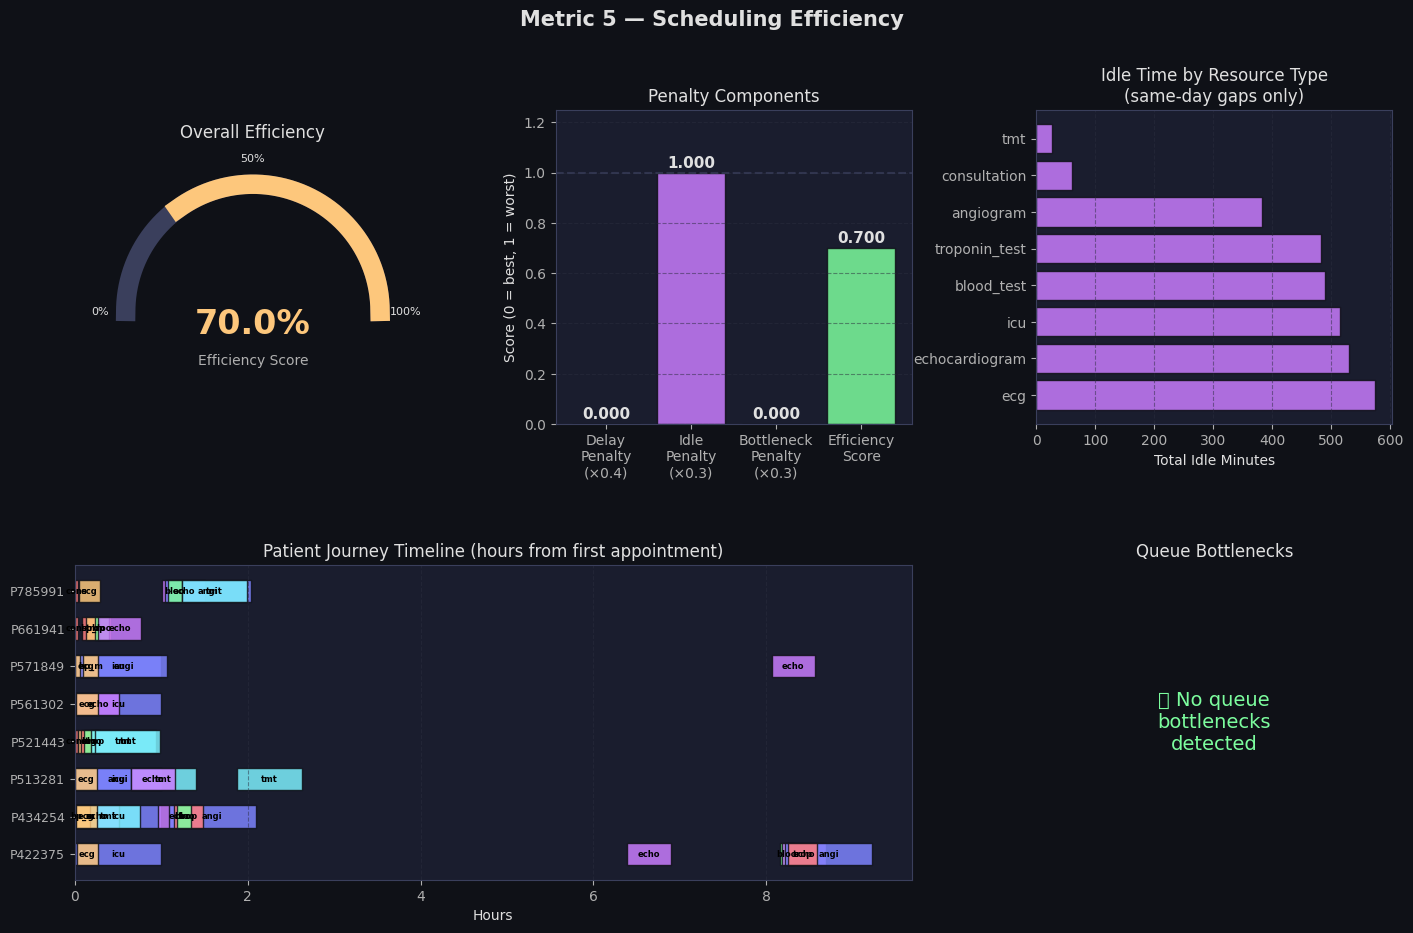

In [31]:
fig = plt.figure(figsize=(17, 10))
fig.suptitle('Metric 5 — Scheduling Efficiency', fontsize=15, fontweight='bold')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

score  = eff['efficiency_score']
g_col  = '#7cfd9e' if score > 0.8 else ('#fdc77c' if score > 0.6 else '#fd7c7c')

# Panel A: Gauge
ax0 = fig.add_subplot(gs[0, 0])
theta      = np.linspace(0, np.pi, 300)
theta_fill = np.linspace(0, np.pi * score, 300)
ax0.plot(np.cos(theta),      np.sin(theta),      color='#3a3f5c', lw=14)
ax0.plot(np.cos(theta_fill), np.sin(theta_fill), color=g_col,     lw=14)
# Labels on gauge
for val, label in [(0,'0%'), (0.5,'50%'), (1.0,'100%')]:
    ang = np.pi * (1 - val)
    ax0.text(1.2*np.cos(ang), 1.2*np.sin(ang), label, ha='center', va='center', fontsize=8)
ax0.text(0, -0.1, f'{score*100:.1f}%', ha='center', va='center',
         fontsize=24, fontweight='bold', color=g_col)
ax0.text(0, -0.42, 'Efficiency Score', ha='center', fontsize=10, color='#b0b0b0')
ax0.set_xlim(-1.4, 1.4); ax0.set_ylim(-0.6, 1.3)
ax0.set_aspect('equal'); ax0.axis('off')
ax0.set_title('Overall Efficiency')

# Panel B: Penalty breakdown waterfall
ax1 = fig.add_subplot(gs[0, 1])
comp_labels = ['Delay\nPenalty\n(×0.4)', 'Idle\nPenalty\n(×0.3)', 'Bottleneck\nPenalty\n(×0.3)', 'Efficiency\nScore']
comp_vals   = [eff['delay_penalty'], eff['idle_penalty'], eff['btn_penalty'], score]
comp_cols   = ['#fd7c7c', '#c87cfd', '#fdc77c', '#7cfd9e']
bars = ax1.bar(comp_labels, comp_vals, color=comp_cols, edgecolor='#0f1117', alpha=0.85)
ax1.axhline(1.0, color='#3a3f5c', lw=1.5, linestyle='--', alpha=0.7)
for bar, val in zip(bars, comp_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 1.25)
ax1.set_title('Penalty Components')
ax1.set_ylabel('Score (0 = best, 1 = worst)')
ax1.grid(True, axis='y')

# Panel C: Idle time by resource
ax2 = fig.add_subplot(gs[0, 2])
if eff['idle_by_resource']:
    ibr = dict(sorted(eff['idle_by_resource'].items(), key=lambda x: -x[1]))
    ax2.barh(list(ibr.keys()), list(ibr.values()), color='#c87cfd', edgecolor='#0f1117', alpha=0.85)
    ax2.set_title('Idle Time by Resource Type\n(same-day gaps only)')
    ax2.set_xlabel('Total Idle Minutes')
    ax2.grid(True, axis='x')
else:
    ax2.text(0.5, 0.5, 'No idle windows\ndetected', ha='center', va='center',
             transform=ax2.transAxes, fontsize=13, color='#7cfd9e')
    ax2.set_title('Idle Time by Resource')
    ax2.axis('off')

# Panel D: Timeline of appointments per patient
ax3 = fig.add_subplot(gs[1, :2])
pids   = list(patient_appts.keys())
colors_appt = {res: ACCENT[i % len(ACCENT)]
               for i, res in enumerate(RESOURCE_POOL.keys())}
for y, pid in enumerate(pids):
    appts_sorted = sorted(patient_appts[pid], key=lambda x: x['scheduled_time'])
    for a in appts_sorted:
        dur   = RESOURCE_POOL.get(a['appointment_type'], {}).get('duration_minutes', 10)
        t0    = a['scheduled_time']
        color = colors_appt.get(a['appointment_type'], '#7c83fd')
        ax3.barh(y, dur/60, left=(t0 - appts_sorted[0]['scheduled_time']).total_seconds()/3600,
                 color=color, edgecolor='#0f1117', alpha=0.85, height=0.6)
        ax3.text(
            (t0 - appts_sorted[0]['scheduled_time']).total_seconds()/3600 + dur/120,
            y, a['appointment_type'][:4], ha='center', va='center',
            fontsize=6, color='black', fontweight='bold')
ax3.set_yticks(range(len(pids)))
ax3.set_yticklabels(pids, fontsize=9)
ax3.set_title('Patient Journey Timeline (hours from first appointment)')
ax3.set_xlabel('Hours')
ax3.grid(True, axis='x')

# Panel E: Bottleneck chart
ax4 = fig.add_subplot(gs[1, 2])
if queue_bottlenecks:
    bnames  = [b['resource'] for b in queue_bottlenecks]
    bdemand = [b['max_demand'] for b in queue_bottlenecks]
    bunits  = [b['available_units'] for b in queue_bottlenecks]
    x = range(len(bnames))
    ax4.bar(x, bdemand, color='#fd7c7c', edgecolor='#0f1117', alpha=0.85, label='Peak Demand')
    ax4.bar(x, bunits,  color='#7cfd9e', edgecolor='#0f1117', alpha=0.6,  label='Available Units')
    ax4.set_xticks(list(x))
    ax4.set_xticklabels([n[:10] for n in bnames], rotation=30, ha='right', fontsize=8)
    ax4.set_title('Queue Bottlenecks')
    ax4.set_ylabel('Count')
    ax4.legend(fontsize=9)
    ax4.grid(True, axis='y')
else:
    ax4.text(0.5, 0.5, '✅ No queue\nbottlenecks\ndetected', ha='center', va='center',
             transform=ax4.transAxes, fontsize=14, color='#7cfd9e')
    ax4.set_title('Queue Bottlenecks')
    ax4.axis('off')

plt.show()


---
## 🧮 Metric 6 — Hungarian Algorithm Cost Matrix

**Cost formula per cell:**
$$
\text{cost}(i,j) = \underbrace{\text{wait\_time\_minutes}}_{\text{slot}_j - \text{now}} \times \underbrace{\frac{1}{\text{priority\_weight}[p_i]}}_{\text{priority factor}} \times \underbrace{\left(1 + \frac{\text{load}_j}{\text{capacity}_j}\right)}_{\text{load factor}}
$$

Incompatible patient-slot pairs (wrong resource type) → **cost = ∞**.  
Scipy `linear_sum_assignment` finds the globally optimal assignment.

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# METRIC 6 — Hungarian Algorithm Cost Matrix
#
# Cost formula per cell (patient i, slot j):
#   cost = wait_time_minutes × priority_factor × load_factor
#
# where:
#   wait_time_minutes = max(0, slot_time − now)
#   priority_factor   = 1 / PRIORITY_WEIGHTS[patient.priority]   (high prio → low cost)
#   load_factor       = 1 + (slot.current_load / slot.capacity)  (busier slot → higher cost)
#
# Cells where slot resource_type ∉ patient.required_appointments → cost = ∞
# ─────────────────────────────────────────────────────────────────────────────

# Load patients with their ACTUAL required_appointments from DB
conn = get_conn(DB_PATH)
pat_rows_full = conn.execute(
    "SELECT patient_id, priority, severity_score, required_appointments FROM patients"
).fetchall()
conn.close()

cm_patients = []
for r in pat_rows_full:
    try:
        req = json.loads(r['required_appointments']) if r['required_appointments'] else []
    except Exception:
        req = []
    # Add all appointment types this patient actually received (from appointments table)
    actual_types = list({a['appointment_type'] for a in ALL_APPTS
                          if a['patient_id'] == r['patient_id']})
    all_req = list(set(req + actual_types))
    cm_patients.append({
        'patient_id':            r['patient_id'],
        'priority':              r['priority'] or 3,
        'severity_score':        r['severity_score'] or 5,
        'required_appointments': all_req,
    })

# Augment with synthetic patients for a richer matrix (at least 8)
np.random.seed(99)
if len(cm_patients) < 8:
    SYNTH_APPTS = [
        ['consultation', 'ecg', 'troponin_test'],
        ['consultation', 'echocardiogram', 'blood_test'],
        ['consultation', 'blood_test'],
        ['consultation', 'tmt', 'ecg'],
        ['consultation', 'angiogram'],
    ]
    for i in range(8 - len(cm_patients)):
        prio = np.random.choice([1,2,3], p=[0.3, 0.4, 0.3])
        cm_patients.append({
            'patient_id':            f'SIM{i+1:02d}',
            'priority':              int(prio),
            'severity_score':        int(np.random.randint(3, 10)),
            'required_appointments': SYNTH_APPTS[i % len(SYNTH_APPTS)],
        })

# Build resource slots
INTERVAL_MAP = {
    'consultation': 2, 'blood_test': 5, 'ecg': 10, 'echocardiogram': 20,
    'tmt': 25, 'angiogram': 30, 'troponin_test': 10, 'cardiac_ct': 45,
    'icu': 5, 'bp_monitoring': 5,
}
base_time = datetime.now()
cm_resources = {}
for res, cfg in RESOURCE_POOL.items():
    if cfg['units'] == 0:
        continue
    interval = INTERVAL_MAP.get(res, 15)
    cm_resources[res] = [
        {'id': f"{res[:3].upper()}{i+1:02d}",
         'time': base_time + timedelta(minutes=interval*(i+1)),
         'capacity': cfg['capacity_per_unit'],
         'current_load': 0}
        for i in range(cfg['units'])
    ]

print(f"Patients for cost matrix : {len(cm_patients)}")
for p in cm_patients:
    print(f"  {p['patient_id']:<12} prio={p['priority']} sev={p['severity_score']:2d}  req={p['required_appointments']}")
print(f"Resource slots total     : {sum(len(v) for v in cm_resources.values())}")


Patients for cost matrix : 8
  P571849      prio=1 sev= 7  req=['icu', 'bp_monitoring', 'ecg', 'angiogram', 'consultation', 'echocardiogram']
  P661941      prio=3 sev= 1  req=['troponin_test', 'bp_monitoring', 'blood_test', 'consultation', 'echocardiogram']
  P434254      prio=1 sev= 5  req=['icu', 'troponin_test', 'bp_monitoring', 'blood_test', 'ecg', 'angiogram', 'tmt', 'consultation', 'echocardiogram']
  P422375      prio=1 sev= 8  req=['icu', 'troponin_test', 'blood_test', 'ecg', 'angiogram', 'consultation', 'echocardiogram']
  P513281      prio=1 sev= 5  req=['icu', 'ecg', 'angiogram', 'tmt', 'consultation', 'echocardiogram']
  P785991      prio=3 sev= 1  req=['blood_test', 'ecg', 'angiogram', 'tmt', 'consultation', 'echocardiogram']
  P521443      prio=2 sev= 4  req=['troponin_test', 'blood_test', 'ecg', 'tmt', 'consultation']
  P561302      prio=1 sev= 7  req=['ecg', 'icu', 'consultation', 'echocardiogram']
Resource slots total     : 42


In [33]:
# ── Build NxM cost matrix ────────────────────────────────────────────────────
all_slots, slot_labels = [], []
for res_type, slots in cm_resources.items():
    for slot in slots:
        all_slots.append({'resource_type': res_type, **slot})
        slot_labels.append(f"{res_type[:8]}::{slot['id']}")

N_P = len(cm_patients)
N_S = len(all_slots)
pat_labels = [p['patient_id'] for p in cm_patients]
cost_matrix = np.full((N_P, N_S), np.inf)

for i, patient in enumerate(cm_patients):
    prio = patient['priority']
    req  = [s.lower().replace(' ', '_') for s in patient['required_appointments']]
    for j, slot in enumerate(all_slots):
        if slot['resource_type'] not in req:
            continue
        slot_time = slot['time']
        wait      = max(0.0, (slot_time - base_time).total_seconds() / 60)
        pf        = 1.0 / PRIORITY_WEIGHTS.get(prio, 1)
        lf        = 1.0 + slot['current_load'] / max(slot['capacity'], 1)
        cost_matrix[i, j] = wait * pf * lf

# ── Solve with Hungarian algorithm ───────────────────────────────────────────
SENTINEL    = 1e9
solver_mat  = np.where(np.isinf(cost_matrix), SENTINEL, cost_matrix)
row_ind, col_ind = linear_sum_assignment(solver_mat)

total_cost  = 0.0
assignments = []
for r, c in zip(row_ind, col_ind):
    raw   = cost_matrix[r, c]
    ok    = not np.isinf(raw)
    assignments.append({
        'patient':        pat_labels[r],
        'priority':       cm_patients[r]['priority'],
        'severity':       cm_patients[r]['severity_score'],
        'slot':           slot_labels[c],
        'resource_type':  all_slots[c]['resource_type'],
        'cost':           float(raw) if ok else np.inf,
        'feasible':       ok,
        'row': r, 'col': c,
    })
    if ok:
        total_cost += float(raw)

finite = cost_matrix[np.isfinite(cost_matrix)]
ms = {
    'shape':         f"{N_P} × {N_S}",
    'finite':        len(finite),
    'infeasible':    int(np.sum(np.isinf(cost_matrix))),
    'min_cost':      round(float(np.min(finite)), 3)  if len(finite) else None,
    'max_cost':      round(float(np.max(finite)), 3)  if len(finite) else None,
    'mean_cost':     round(float(np.mean(finite)), 3) if len(finite) else None,
    'std_cost':      round(float(np.std(finite)),  3) if len(finite) else None,
    'total_optimal': round(total_cost, 4),
    'feasible_asn':  sum(1 for a in assignments if a['feasible']),
}

print(f"Cost matrix shape      : {ms['shape']}")
print(f"Finite (valid) cells   : {ms['finite']}")
print(f"Infeasible (∞) cells   : {ms['infeasible']}")
if finite.size:
    print(f"Cost range             : {ms['min_cost']} – {ms['max_cost']}")
    print(f"Mean ± std             : {ms['mean_cost']} ± {ms['std_cost']}")
print(f"Total optimal cost     : {ms['total_optimal']}")
print(f"Feasible assignments   : {ms['feasible_asn']} / {len(assignments)}")
print()
print(f"{'✅/❌'} {'Patient':<12} {'Priority':<10} {'Sev':>3}  {'Assigned Slot':<40}  Cost")
print("-"*85)
for a in assignments:
    icon   = '✅' if a['feasible'] else '❌'
    pname  = PRIORITY_NAMES.get(a['priority'], '?')
    cost_s = f"{a['cost']:.3f}" if a['feasible'] else "∞"
    print(f"{icon}  {a['patient']:<12} {pname:<10} {a['severity']:>3}  {a['slot']:<40}  {cost_s}")


Cost matrix shape      : 8 × 42
Finite (valid) cells   : 231
Infeasible (∞) cells   : 105
Cost range             : 0.2 – 60.0
Mean ± std             : 5.604 ± 8.656
Total optimal cost     : 10.4
Feasible assignments   : 8 / 8

✅/❌ Patient      Priority   Sev  Assigned Slot                             Cost
-------------------------------------------------------------------------------------
✅  P571849      Emergency    7  consulta::CON03                           0.600
✅  P661941      Routine      1  consulta::CON01                           2.000
✅  P434254      Emergency    5  bp_monit::BP_01                           0.500
✅  P422375      Emergency    8  consulta::CON04                           0.800
✅  P513281      Emergency    5  icu::ICU01                                0.500
✅  P785991      Routine      1  consulta::CON02                           4.000
✅  P521443      Urgent       4  blood_te::BLO01                           1.000
✅  P561302      Emergency    7  consulta::CON05

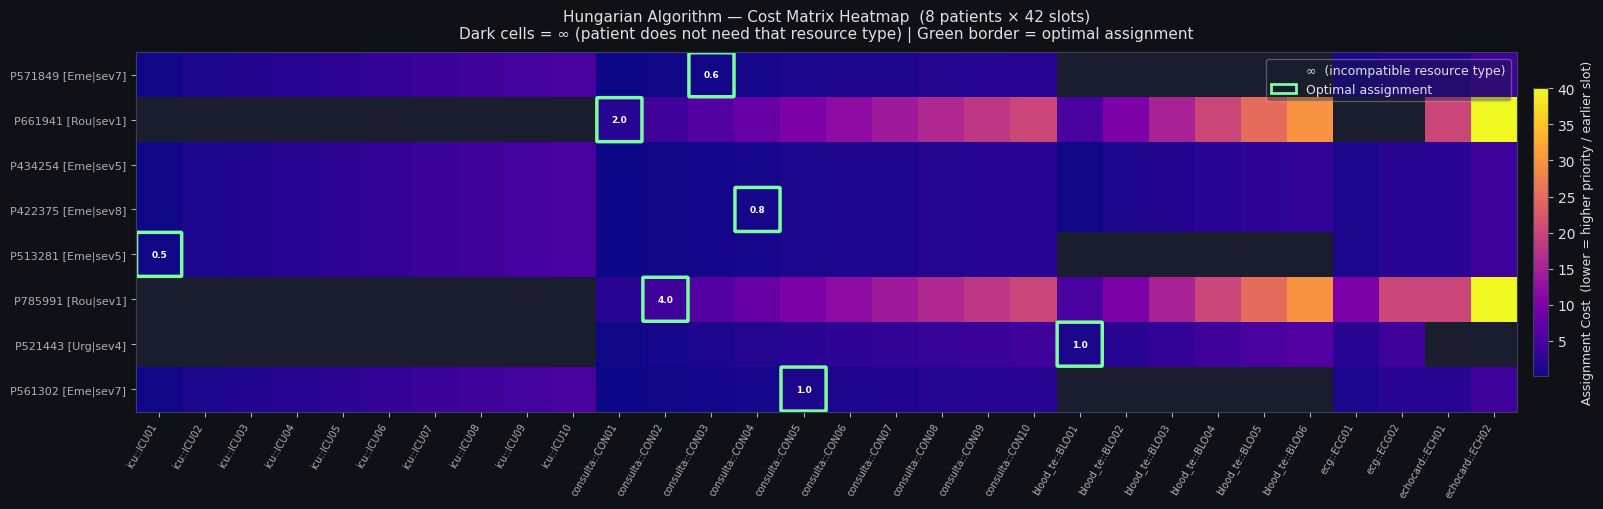

In [34]:
# ── Visualization A: Cost Matrix Heatmap ─────────────────────────────────────
N_P_SHOW = min(N_P, 12)
N_S_SHOW = min(N_S, 30)

sub   = cost_matrix[:N_P_SHOW, :N_S_SHOW].copy()
disp  = np.where(np.isinf(sub), np.nan, sub)

fig, ax = plt.subplots(figsize=(max(16, N_S_SHOW * 0.6), max(5, N_P_SHOW * 0.65)))
fig.patch.set_facecolor('#0f1117')

cmap = plt.cm.plasma.copy()
cmap.set_bad('#1a1d2e')
finite_disp = disp[~np.isnan(disp)]
vmin = float(np.min(finite_disp)) if finite_disp.size else 0
vmax = float(np.max(finite_disp)) if finite_disp.size else 1

im = ax.imshow(disp, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)

# Overlay optimal assignment boxes + cost labels
for a in assignments:
    r, c = a['row'], a['col']
    if r < N_P_SHOW and c < N_S_SHOW:
        rect = mpatches.FancyBboxPatch(
            (c-0.47, r-0.47), 0.94, 0.94,
            boxstyle='round,pad=0.02',
            linewidth=2.5, edgecolor='#7cfd9e', facecolor='none',
        )
        ax.add_patch(rect)
        if a['feasible']:
            ax.text(c, r, f"{a['cost']:.1f}", ha='center', va='center',
                    fontsize=6.5, color='white', fontweight='bold')

# Axis labels
ax.set_yticks(range(N_P_SHOW))
def _ytlbl(i):
    pn = PRIORITY_NAMES.get(cm_patients[i]['priority'], '?')[:3]
    sv = cm_patients[i]['severity_score']
    return f"{pat_labels[i]} [{pn}|sev{sv}]"
ax.set_yticklabels([_ytlbl(i) for i in range(N_P_SHOW)], fontsize=8)
ax.set_xticks(range(N_S_SHOW))
ax.set_xticklabels([slot_labels[j][:20] for j in range(N_S_SHOW)],
                   rotation=60, ha='right', fontsize=7)

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.01)
cbar.set_label('Assignment Cost  (lower = higher priority / earlier slot)', fontsize=9)
cbar.ax.tick_params(labelcolor='#e0e0e0')

h1 = mpatches.Patch(color='#1a1d2e',  label='∞  (incompatible resource type)')
h2 = mpatches.Patch(edgecolor='#7cfd9e', facecolor='none', lw=2, label='Optimal assignment')
ax.legend(handles=[h1, h2], loc='upper right', fontsize=9, framealpha=0.35)
ax.set_title(
    f'Hungarian Algorithm — Cost Matrix Heatmap  ({N_P} patients × {N_S} slots)\n'
    'Dark cells = ∞ (patient does not need that resource type) | Green border = optimal assignment',
    fontsize=11, pad=10)
plt.tight_layout()
plt.show()


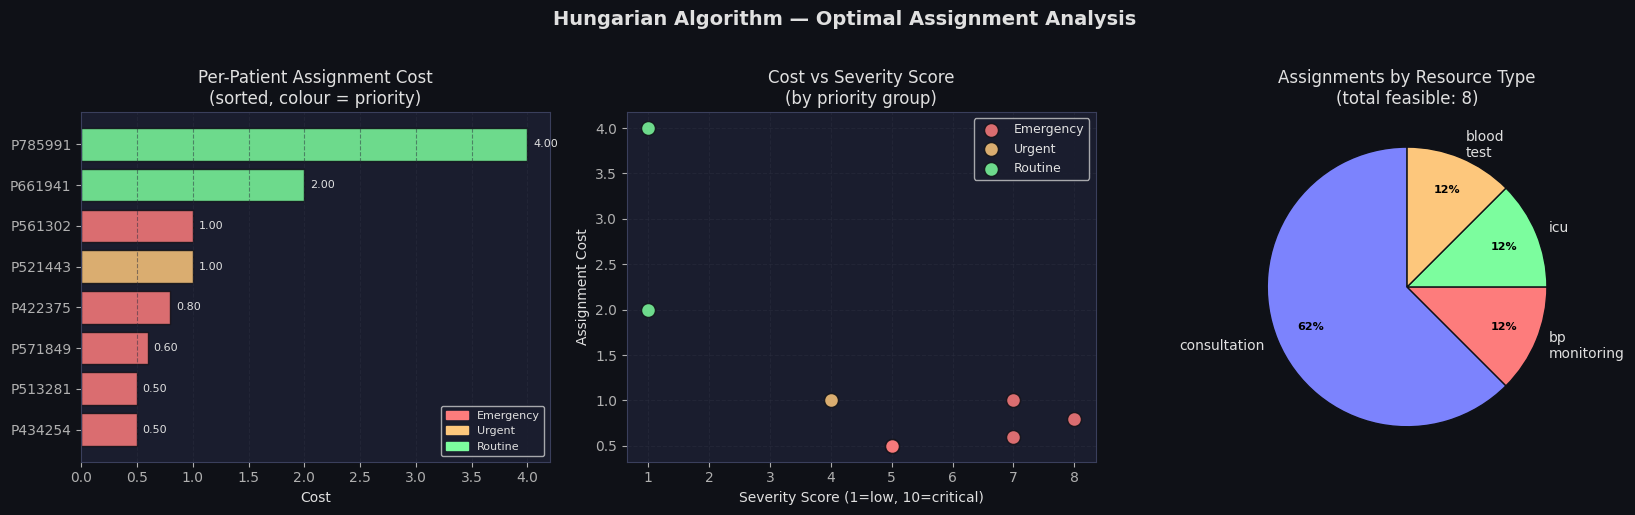

In [35]:
# ── Visualization B: Assignment analysis ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Hungarian Algorithm — Optimal Assignment Analysis',
             fontsize=14, fontweight='bold', y=1.02)

feasible_a = [a for a in assignments if a['feasible']]

# Panel A: Per-patient cost bar coloured by priority
ax = axes[0]
fa_sorted  = sorted(feasible_a, key=lambda x: x['cost'])
fa_names   = [a['patient'] for a in fa_sorted]
fa_costs   = [a['cost'] for a in fa_sorted]
fa_colors  = [PRIORITY_COLORS.get(a['priority'], ACCENT[0]) for a in fa_sorted]
bars = ax.barh(fa_names, fa_costs, color=fa_colors, edgecolor='#0f1117', alpha=0.85)
for bar, val in zip(bars, fa_costs):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)
ax.set_title('Per-Patient Assignment Cost\n(sorted, colour = priority)')
ax.set_xlabel('Cost')
ax.grid(True, axis='x')
patches = [mpatches.Patch(color=PRIORITY_COLORS[k], label=PRIORITY_NAMES[k])
           for k in [1,2,3]]
ax.legend(handles=patches, fontsize=8)

# Panel B: Average cost by priority + severity scatter
ax = axes[1]
prio_grp = {}
for a in feasible_a:
    prio_grp.setdefault(a['priority'], []).append((a['severity'], a['cost']))
for prio, pts in sorted(prio_grp.items()):
    sevs, costs = zip(*pts)
    ax.scatter(sevs, costs, color=PRIORITY_COLORS[prio],
               s=100, edgecolors='#0f1117', alpha=0.85, zorder=3,
               label=PRIORITY_NAMES[prio])
ax.set_title('Cost vs Severity Score\n(by priority group)')
ax.set_xlabel('Severity Score (1=low, 10=critical)')
ax.set_ylabel('Assignment Cost')
ax.legend(fontsize=9)
ax.grid(True)

# Panel C: Resource type distribution of assignments
ax = axes[2]
res_counts = {}
for a in feasible_a:
    res_counts[a['resource_type']] = res_counts.get(a['resource_type'], 0) + 1
if res_counts:
    rkeys  = list(res_counts.keys())
    rvals  = [res_counts[k] for k in rkeys]
    rcols  = [ACCENT[i % len(ACCENT)] for i in range(len(rkeys))]
    wedges, texts, autotexts = ax.pie(
        rvals, labels=[r.replace('_','\n') for r in rkeys], colors=rcols,
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor='#0f1117'), pctdistance=0.75,
    )
    for at in autotexts:
        at.set_color('black'); at.set_fontweight('bold'); at.set_fontsize(8)
ax.set_title(f'Assignments by Resource Type\n(total feasible: {len(feasible_a)})')

plt.tight_layout()
plt.show()


---
## 📋 Full Evaluation Summary Dashboard

C:\Users\ADITH\AppData\Local\Temp\ipykernel_26716\537990176.py:81: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


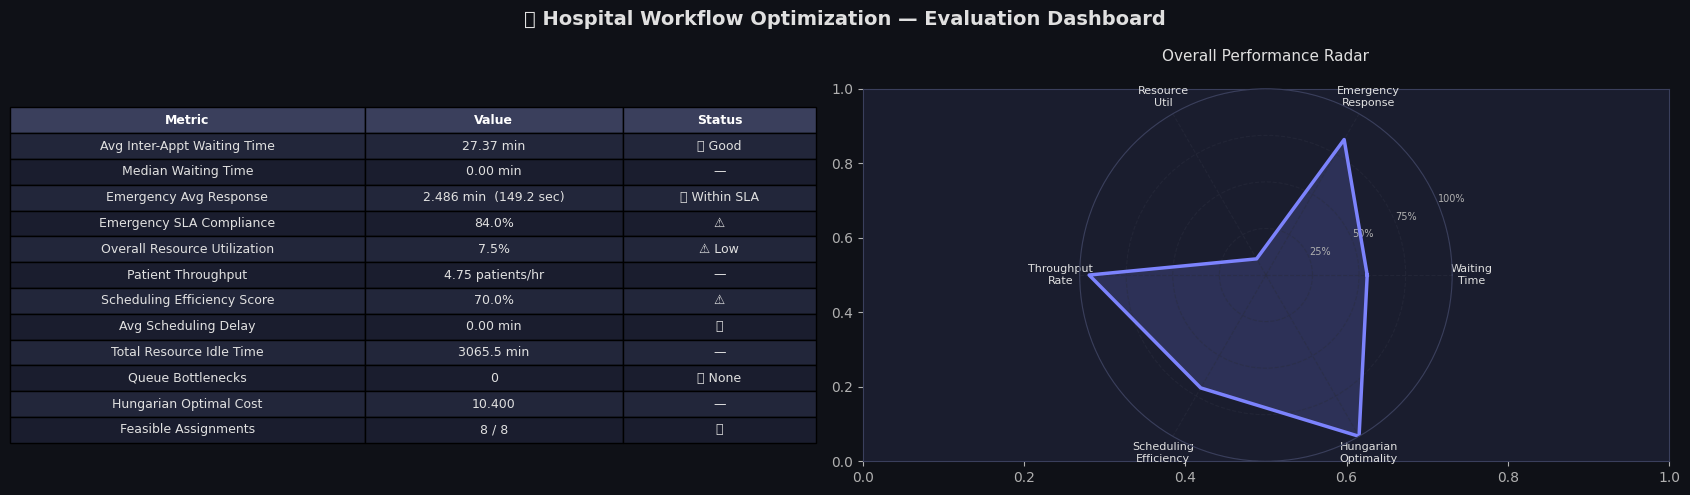


✅ Evaluation complete — 2026-03-10 18:44:19


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# FULL EVALUATION SUMMARY DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle('🏥 Hospital Workflow Optimization — Evaluation Dashboard',
             fontsize=14, fontweight='bold')

# ── Left: summary table ──────────────────────────────────────────────────────
ax = axes[0]
ax.axis('off')
summary_rows = [
    ['Avg Inter-Appt Waiting Time',   f"{stats['mean']:.2f} min",
     '✅ Good' if stats['mean'] < 30 else '⚠️ High'],
    ['Median Waiting Time',           f"{stats['median']:.2f} min", '—'],
    ['Emergency Avg Response',        f"{np.mean(ert_values):.3f} min  ({np.mean(ert_values)*60:.1f} sec)",
     '✅ Within SLA' if np.mean(ert_values) <= SLA_EMERGENCY_MIN else '❌ SLA Breach'],
    ['Emergency SLA Compliance',      f"{sla_compliance:.1f}%",
     '✅' if sla_compliance >= 95 else ('⚠️' if sla_compliance >= 80 else '❌')],
    ['Overall Resource Utilization',  f"{overall_util*100:.1f}%",
     '✅' if 0.3 <= overall_util <= 0.85 else ('⚠️ Low' if overall_util < 0.3 else '⚠️ Overload')],
    ['Patient Throughput',            f"{total/window_h:.2f} patients/hr", '—'],
    ['Scheduling Efficiency Score',   f"{eff['efficiency_score']*100:.1f}%",
     '✅' if eff['efficiency_score'] >= 0.8 else ('⚠️' if eff['efficiency_score'] >= 0.6 else '❌')],
    ['Avg Scheduling Delay',          f"{eff['avg_delay']:.2f} min",
     '✅' if eff['avg_delay'] < 10 else '⚠️ High'],
    ['Total Resource Idle Time',      f"{eff['total_idle']:.1f} min", '—'],
    ['Queue Bottlenecks',             str(len(eff['queue_bottlenecks'])),
     '✅ None' if not eff['queue_bottlenecks'] else '⚠️ Present'],
    ['Hungarian Optimal Cost',        f"{ms['total_optimal']:.3f}", '—'],
    ['Feasible Assignments',          f"{ms['feasible_asn']} / {len(assignments)}",
     '✅' if ms['feasible_asn'] == len(assignments) else '⚠️'],
]
table = ax.table(
    cellText=summary_rows,
    colLabels=['Metric', 'Value', 'Status'],
    colWidths=[0.44, 0.32, 0.24],
    cellLoc='center', loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)
for col in range(3):
    table[0, col].set_facecolor('#3a3f5c')
    table[0, col].set_text_props(fontweight='bold', color='white')
for row in range(1, len(summary_rows)+1):
    bg = '#1a1d2e' if row % 2 == 0 else '#22263a'
    for col in range(3):
        table[row, col].set_facecolor(bg)
        table[row, col].set_text_props(color='#e0e0e0')

# ── Right: score radar ───────────────────────────────────────────────────────
ax2 = plt.subplot(1, 2, 2, polar=True, facecolor='#1a1d2e')
radar_labels = ['Waiting\nTime', 'Emergency\nResponse', 'Resource\nUtil',
                'Throughput\nRate', 'Scheduling\nEfficiency', 'Hungarian\nOptimality']
# Normalise each to 0–1 (1 = best)
wt_score    = max(0.0, 1.0 - stats['mean'] / 60)                   # <1 min ideal
ert_score   = sla_compliance / 100.0
util_score  = 1.0 - abs(overall_util - 0.75) / 0.75                # ideal ~75%
tp_score    = min(1.0, (total/window_h) / 5.0)                     # 5/hr = 100%
eff_sc      = eff['efficiency_score']
hung_sc     = ms['feasible_asn'] / max(len(assignments), 1)
radar_vals  = [wt_score, ert_score, util_score, tp_score, eff_sc, hung_sc]
radar_vals  = [max(0.0, min(1.0, v)) for v in radar_vals]

N = len(radar_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
vals_r = radar_vals + [radar_vals[0]]
angles += [angles[0]]
ax2.plot(angles, vals_r, color=ACCENT[0], lw=2.5)
ax2.fill(angles, vals_r, color=ACCENT[0], alpha=0.2)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(radar_labels, fontsize=8, color='#e0e0e0')
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7, color='#b0b0b0')
ax2.set_ylim(0, 1)
ax2.set_title('Overall Performance Radar', pad=20, fontsize=11)
ax2.spines['polar'].set_color('#3a3f5c')
ax2.grid(color='#2a2d3e')

plt.tight_layout()
plt.show()
print(f"\n✅ Evaluation complete — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
